In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, transforms
import os
import numpy as np
import torch_directml
import matplotlib.pyplot as plt

In [2]:
# Дата Трансформер +
data_transforms = {
    'train' : transforms.Compose([
        transforms.RandomResizedCrop(224), # Делаеь случайный кроп от 8% до 100% с изменением размера
        transforms.RandomHorizontalFlip(), # Случайная возможность отзеркаливания по горизонтали
        transforms.ToTensor(), # Приводим к тензору
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Нормализуем по каждому каналу
    ]),
    'val' : transforms.Compose([
        transforms.Resize(256), # Изменение размера
        transforms.CenterCrop(224), # Приводим к нужному размеру
        transforms.ToTensor(), # Приводим к тензору
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Нормализуем
    ])
}

In [5]:
# Подготавливаем данные
data_dir = './source/hymenoptera_data'
image_datasets = {x : datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x : torch.utils.data.DataLoader(image_datasets[x],
                                              batch_size=4,
                                              shuffle=True)
               for x in ['train', 'val']}
dataset_sizes = {x : len(image_datasets[x])
                 for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(class_names)
print(len(dataloaders['train']))
print(len(dataloaders['val']))
print(dataset_sizes['train'])
print(dataset_sizes['val'])

['ants', 'bees']
61
39
244
153


In [6]:
# Натренированная модель
model_conv = torchvision.models.resnet18(pretrained=True)

C:\Alexey\Projects\Udemy\NN_learning\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Alexey\Projects\Udemy\NN_learning\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\korol/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100.0%


In [8]:
# Выключаем градиент для всех параметров
for param in model_conv.parameters():
    param.requires_grad = False

In [9]:
# Меняем последний слой
num_features = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_features, 2)

In [11]:
# Выбираем устройство
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(torch.cuda.get_device_name(0))
elif torch_directml.is_available():
   device = torch_directml.device()
   print(torch_directml.device_name(0))
else:
    device = torch.device("cpu")
    print("cpu")

AMD Radeon RX 6800S 


In [12]:
# Переносим
model_conv = model_conv.to(device)

In [15]:
# Изначальные настройки модели и понимание данных
iteraton = 0
correct = 0
for (inputs, labels) in dataloaders['train']:
    if iteraton == 1:
        break
    inputs = inputs.to(device)
    labels = labels.to(device)
    print(inputs.shape)
    print(labels.shape)
    print(labels)
    outputs = model_conv(inputs)
    print(outputs)
    _, predicted = torch.max(outputs.data, 1)
    print(predicted)
    print(predicted.shape)
    correct += (predicted == labels).sum()
    print(correct)
    iteraton += 1

torch.Size([4, 3, 224, 224])
torch.Size([4])
tensor([0, 0, 0, 0], device='privateuseone:0')
tensor([[-0.9829,  0.1544],
        [-0.7857,  0.3794],
        [-1.1710,  0.4344],
        [-1.5780, -0.2148]], device='privateuseone:0',
       grad_fn=<AddmmBackward0>)
tensor([1, 1, 1, 1], device='privateuseone:0')
torch.Size([4])
tensor(0, device='privateuseone:0')


In [16]:
# Настройки
criterion = nn.CrossEntropyLoss(reduction='mean')
# Если нужно оптимизировать несколько слоёв, то используется lambda функция
# filter(lambda p: p.requires_grad, model.parameters())
optimizer = optim.SGD(filter(lambda p: p.requires_grad, model_conv.parameters()),
                      lr=0.001,
                      momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer,
                                       step_size=7,
                                       gamma=0.1)

In [18]:
# Обучение
epochs = 25
for epoch in range(epochs):
    model_conv.train()
    correct = 0
    for (images, labels) in dataloaders['train']:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model_conv(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum()
    accuracy = correct / dataset_sizes['train'] * 100
    print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.3f}, Accuracy: {accuracy:.3f}%")
    exp_lr_scheduler.step()

Epoch 0/25, Loss: 1.388, Accuracy: 77.869%
Epoch 1/25, Loss: 0.060, Accuracy: 83.607%
Epoch 2/25, Loss: 0.425, Accuracy: 88.115%
Epoch 3/25, Loss: 0.009, Accuracy: 84.016%
Epoch 4/25, Loss: 0.151, Accuracy: 86.885%
Epoch 5/25, Loss: 0.514, Accuracy: 81.557%
Epoch 6/25, Loss: 1.358, Accuracy: 83.607%
Epoch 7/25, Loss: 0.292, Accuracy: 84.016%
Epoch 8/25, Loss: 0.362, Accuracy: 82.787%
Epoch 9/25, Loss: 0.111, Accuracy: 84.016%
Epoch 10/25, Loss: 0.191, Accuracy: 88.525%
Epoch 11/25, Loss: 0.119, Accuracy: 82.787%
Epoch 12/25, Loss: 0.199, Accuracy: 89.344%
Epoch 13/25, Loss: 0.016, Accuracy: 81.967%
Epoch 14/25, Loss: 0.693, Accuracy: 88.115%
Epoch 15/25, Loss: 1.062, Accuracy: 80.738%
Epoch 16/25, Loss: 0.309, Accuracy: 89.344%
Epoch 17/25, Loss: 0.298, Accuracy: 85.246%
Epoch 18/25, Loss: 0.589, Accuracy: 82.787%
Epoch 19/25, Loss: 0.952, Accuracy: 84.836%
Epoch 20/25, Loss: 0.148, Accuracy: 86.066%
Epoch 21/25, Loss: 0.335, Accuracy: 83.607%
Epoch 22/25, Loss: 0.010, Accuracy: 77.869

In [20]:
# Проверяем на тесте
model_conv.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for (images, labels) in dataloaders['val']:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_conv(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum()
    print(f"test accuracy: {correct / total * 100:.3f}%")

test accuracy: 96.078%


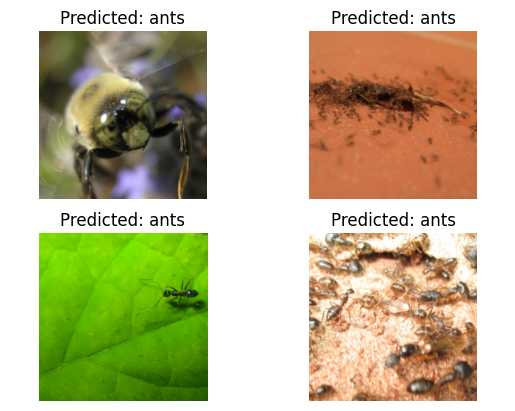

In [41]:
# Визуализация
fig = plt.figure()
show_batch = 0
index = 0
with torch.no_grad():
    for (images, labels) in dataloaders['val']:
        if show_batch == 1:
            break
        show_batch += 1
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_conv(images)
        _, predicted = torch.max(outputs, 1)

        for i in range(4):
            plt.axis('off')
            ax = plt.subplot(2, 2, index + 1)
            ax.axis('off')
            ax.set_title(f"Predicted: {class_names[predicted[i]]}")
            input_img = images[i].cpu().permute(1,2,0)
            mean = [0.485, 0.456, 0.406]
            std = [0.229, 0.224, 0.225]
            input_img = input_img * torch.tensor(std) + torch.tensor(mean)
            input_img = torch.clip(input_img, 0, 1)
            plt.imshow(input_img)
            index += 1